# Notebook 2 Baseline Prediction

## Import Library

In [1]:
import pandas as pd
import numpy as np
import os
import random

# for visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# for fastai
from fastai.vision.all import *
from sklearn.metrics import log_loss

# for metrics
from sklearn.metrics import log_loss

In [2]:
# Allow full column width display in Pandas
pd.set_option('display.max_colwidth', None)

## Load Task-1 Trained Model

In [3]:
# Import model
model_path = Path('/kaggle/input/task-1-model')  
learn = load_learner(model_path/'wildlife_baseline_v3.pkl')

/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [4]:
# Check the model was loaded
learn.model

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

## Load train data

In [5]:
trn_label = pd.read_csv('/kaggle/input/competition-files/train_labels.csv')
trn_fea = pd.read_csv('/kaggle/input/competition-files/train_features.csv')

## Load test data

In [6]:
# Read the CSV
test_df = pd.read_csv('/kaggle/input/competition-files/test_features.csv')
test_df.head()

,id,filepath,site
0,ZJ016488,test_features/ZJ016488.jpg,S0082
1,ZJ016489,test_features/ZJ016489.jpg,S0040
2,ZJ016490,test_features/ZJ016490.jpg,S0040
3,ZJ016491,test_features/ZJ016491.jpg,S0041
4,ZJ016492,test_features/ZJ016492.jpg,S0040


In [7]:
# Get list of image paths
test_dir = Path('/kaggle/input/competition-files/') 
test_files = [test_dir/f for f in test_df['filepath']]
print("Loaded image count:", len(test_files))     # should be 4464

Loaded image count: 4464


# 1. Check for validation set

In [8]:
# Check for validation set
len(learn.dls.valid.items)

0

We found that the imported model wasn't the content validation set, so we decided to recreate the data block as task 1.

In [9]:
# Merge train features and labels on 'id'
df = pd.merge(trn_fea, trn_label, on='id')

# Preview merged dataframe
df.head(5)

,id,filepath,site,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ000000,train_features/ZJ000000.jpg,S0120,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ZJ000001,train_features/ZJ000001.jpg,S0069,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,ZJ000002,train_features/ZJ000002.jpg,S0009,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ZJ000003,train_features/ZJ000003.jpg,S0008,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,ZJ000004,train_features/ZJ000004.jpg,S0036,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [10]:
# Convert one-hot columns into a single label column
classes = ['antelope_duiker', 'bird', 'blank', 'civet_genet', 'hog', 'leopard', 'monkey_prosimian', 'rodent']
df['label'] = df[classes].idxmax(axis=1)

# Check result for id and result
df[['id', 'label']].head(5)

,id,label
0,ZJ000000,bird
1,ZJ000001,monkey_prosimian
2,ZJ000002,bird
3,ZJ000003,monkey_prosimian
4,ZJ000004,leopard


In [11]:
# Add full image path
df['image_path'] = '/kaggle/input/competition-files/' + df['filepath']

# Check path
df[['filepath', 'image_path']].head(5)

,filepath,image_path
0,train_features/ZJ000000.jpg,/kaggle/input/competition-files/train_features/ZJ000000.jpg
1,train_features/ZJ000001.jpg,/kaggle/input/competition-files/train_features/ZJ000001.jpg
2,train_features/ZJ000002.jpg,/kaggle/input/competition-files/train_features/ZJ000002.jpg
3,train_features/ZJ000003.jpg,/kaggle/input/competition-files/train_features/ZJ000003.jpg
4,train_features/ZJ000004.jpg,/kaggle/input/competition-files/train_features/ZJ000004.jpg


In [12]:
# Recreate DataBlock with validation split
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('image_path'),
    get_y=ColReader('label'),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),
)

In [13]:
# Create DataLoaders
dls = dblock.dataloaders(df)

In [14]:
# Assign recreated dataloaders to learner
learn.dls = dls

In [15]:
# Check for validation set
len(learn.dls.valid.items)

3297

As the vallidation set is ready we can go for the next step

# 2. Repeat the baseline training
For better result using unfreeze + lower LR.

SuggestedLRs(valley=1.4454397387453355e-05)

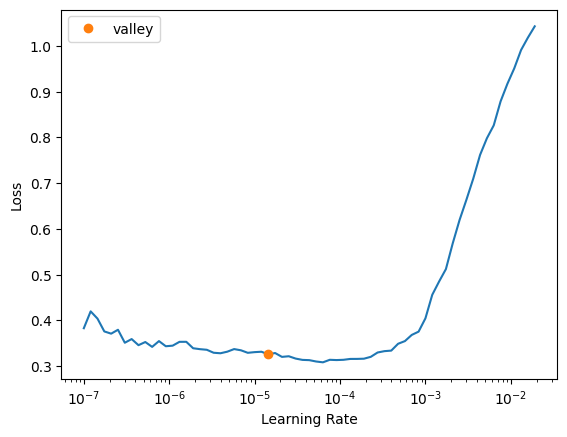

In [16]:
learn.lr_find()
# Result: SuggestedLRs(valley=3.0199516913853586e-05)

In [17]:
# learn.fine_tune(5, base_lr=3e-5)
learn.unfreeze()
learn.fit_one_cycle(5, lr_max=slice(1e-6, 3e-5))

epoch,train_loss,valid_loss,accuracy,time
0,0.304166,0.401214,0.871095,01:02
1,0.289128,0.385570,0.875341,00:47
2,0.257186,0.377002,0.881711,00:46
3,0.247973,0.375773,0.880801,00:47
4,0.222353,0.370152,0.882014,00:47


In [18]:
preds, targs = learn.get_preds(ds_idx=1)  # ds_idx=1 for validation set

# 3. Set up the competition metric (Log Loss)

In [19]:
# Get list of class names in the same order as model output
class_names = learn.dls.vocab
class_names

['antelope_duiker', 'bird', 'blank', 'civet_genet', 'hog', 'leopard', 'monkey_prosimian', 'rodent']

In [20]:
# Convert target indices to one-hot encoding
targs_onehot = np.eye(len(class_names))[targs.numpy()]
targs_onehot

array([[0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

Use log loss as the validation metric.

In [21]:
# Calculate log loss
val_log_loss = log_loss(targs_onehot, preds.numpy())
print(f'Validation Log Loss: {val_log_loss:.5f}')

Validation Log Loss: 0.36841


# 4. Prediction Pipeline

In [22]:
# Create test dataloader from existing DataLoaders
test_dl = learn.dls.test_dl(test_files)

In [23]:
# Get predictions
preds, _ = learn.get_preds(dl=test_dl)

In [24]:
# Check shape (should be num_test_images x num_classes)
print(preds.shape)

torch.Size([4464, 8])


In [25]:
print(test_df.columns)

Index(['id', 'filepath', 'site'], dtype='object')


In [26]:
# Create DataFrame with predictions
preds_df = pd.DataFrame(preds.numpy(), columns=learn.dls.vocab)

# 5. Save Submission Format

In [27]:
# Add row_id from test_features.csv
preds_df.insert(0, 'id', test_df['id'])

In [28]:
# Save
preds_df.to_csv('submission.csv', index=False)

In [29]:
# print out the format
df = pd.read_csv('/kaggle/input/competition-files/submission_format.csv')
df.head()

,id,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ016488,0.048233,0.189185,0.044914,0.199588,0.106118,0.132915,0.166410,0.112637
1,ZJ016489,0.097078,0.061400,0.026409,0.241530,0.144344,0.051780,0.287811,0.089648
2,ZJ016490,0.124658,0.089101,0.189225,0.174494,0.180540,0.079995,0.085672,0.076314
3,ZJ016491,0.109966,0.048397,0.055598,0.323600,0.322356,0.063252,0.008160,0.068671
4,ZJ016492,0.165742,0.184610,0.005431,0.136806,0.000389,0.122078,0.151521,0.233423


In [30]:
# print out to check if match the format
df = pd.read_csv('submission.csv')
df.head()

,id,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ016488,2.481408e-01,0.004574,2.859033e-01,0.361395,0.001662,0.023021,1.338524e-03,7.396560e-02
1,ZJ016489,7.480593e-01,0.176287,2.194078e-03,0.040427,0.022231,0.004205,4.880597e-03,1.716229e-03
2,ZJ016490,7.613571e-01,0.000237,8.047670e-05,0.226371,0.011446,0.000031,4.059431e-04,7.166585e-05
3,ZJ016491,1.008309e-10,0.000011,6.183491e-09,0.000018,0.000052,0.999918,9.970315e-10,5.333070e-07
4,ZJ016492,7.672101e-02,0.294229,4.855921e-02,0.008193,0.010229,0.003262,5.202184e-01,3.858829e-02


# Submit to Kaggle & Record Public Score

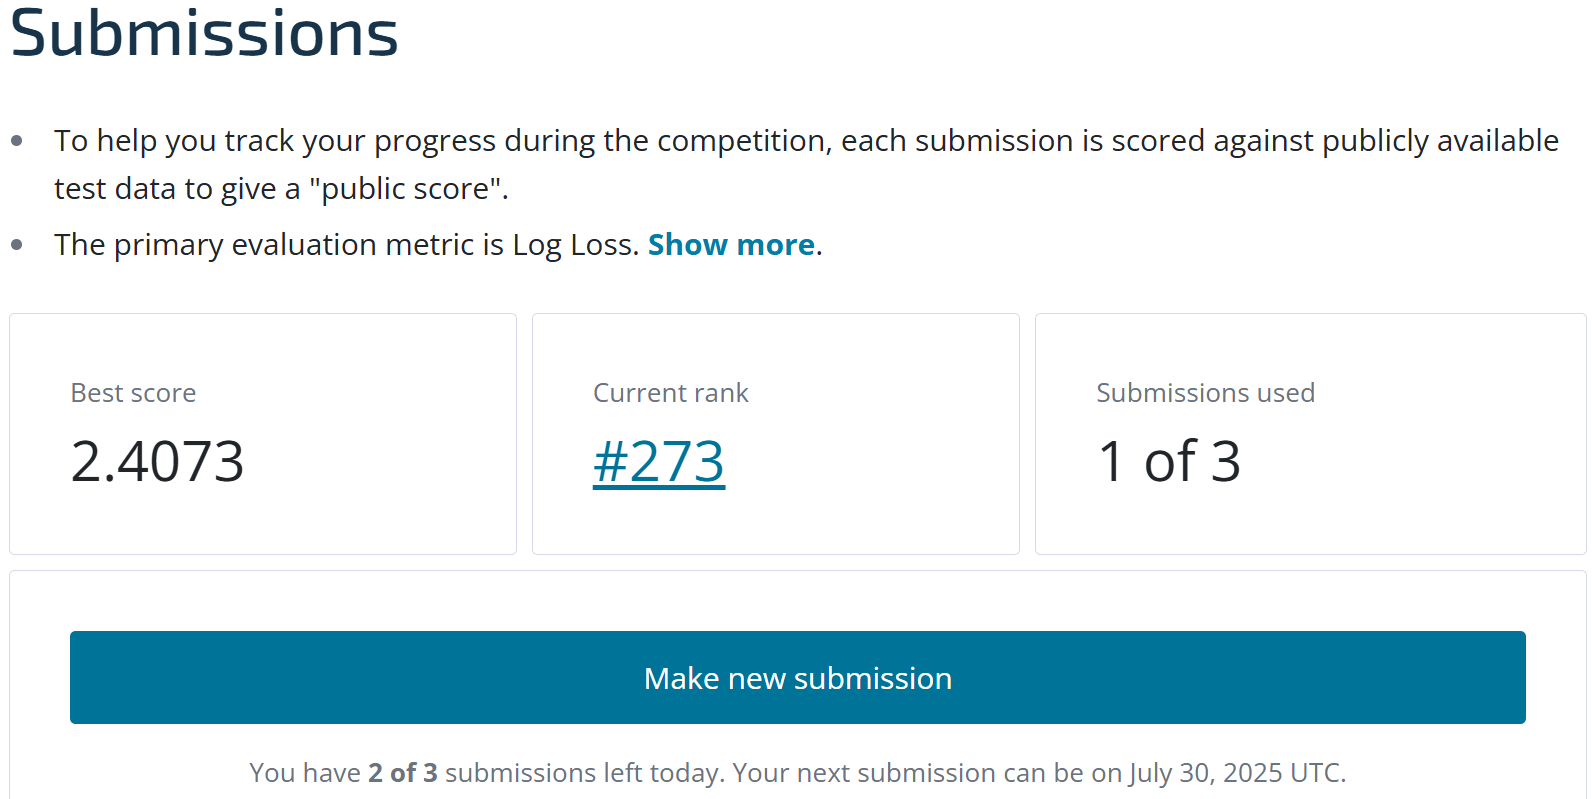

Current score: 2.4073 (The lower the better)

# 6. Reflection

- Our validation log loss was around 0.3, while the leaderboard test log loss was 2.4073, indicating a significant drop in performance on unseen data.
- This may indicate that our model may be overfitting the validation set or that the test distribution differs from the validation set.
- Compared to the top leaderboard score, which was 0.5352, showing much better generalisation.
- This comparison highlights the need for better regularization, data augmentation, or model tuning to improve performance on real-world data.